# FM-Latent Decoder — FALCON Challenge

Flow Matching decoder that:
1. Compresses raw spike counts to a 32-dim PCA latent during training
2. Learns a velocity field `V_θ(x_τ, h, τ) → R^out_dim`
3. At inference, integrates the field with a simple Euler ODE to decode

 ## Environment check & installs

In [11]:
import subprocess, sys

# Install FALCON if not already present
try:
    import falcon_challenge
    print("falcon_challenge already installed")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "falcon-challenge"])

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

falcon_challenge already installed
PyTorch : 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## 1) Imports

In [12]:
from __future__ import annotations

import os
import glob
import copy
from typing import List, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from falcon_challenge.config import FalconConfig, FalconTask
from falcon_challenge.dataloaders import load_nwb
from falcon_challenge.interface import BCIDecoder
import matplotlib.pyplot as plt
import os, subprocess, sys

## 2)Hyperparameters and Data Download


In [38]:
DANDISET_ID = "000954"
SUBJECT_TO_LOCAL = {
    "sub-HumanPitt-held-in-calib":  "data/h1/held_in_calib",
    "sub-HumanPitt-held-out-calib": "data/h1/held_out_calib",
    "sub-HumanPitt-held-in-minival": "data/h1/minival",
}

def _needs_download(mapping):
    for sub, local_path in mapping.items():
        if not os.path.isdir(local_path) or not any(f.endswith(".nwb") for f in os.listdir(local_path)):
            return True
    return False

if _needs_download(SUBJECT_TO_LOCAL):
    print("Downloading FALCON H1 data from DANDI ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dandi"])
    from dandi.download import download as dandi_download

    for sub, local_path in SUBJECT_TO_LOCAL.items():
        os.makedirs(local_path, exist_ok=True)
        print(f"  {sub} → {local_path}")
        dandi_download(
            urls=[f"https://api.dandiarchive.org/api/dandisets/{DANDISET_ID}/versions/draft/assets/?path={sub}"],
            output_dir=local_path,
        )
    print("Download complete.")
else:
    print("All data present — skipping download.")

# Confirm paths and file counts
print("\nData paths:")
for sub, local_path in SUBJECT_TO_LOCAL.items():
    abs_path = os.path.abspath(local_path)
    if os.path.isdir(local_path):
        # find nwb files
        nwb_files = []
        for root, dirs, files in os.walk(local_path):
            nwb_files += [os.path.join(root, f) for f in files if f.endswith(".nwb")]
        print(f"  {abs_path}: {len(nwb_files)} NWB files")
        # If nested, print actual location
        if nwb_files:
            actual_dir = os.path.dirname(nwb_files[0])
            if os.path.abspath(actual_dir) != abs_path:
                print(f"    ↳ actual NWB location: {actual_dir}")
    else:
        print(f"  {abs_path}: NOT FOUND")

  sub-HumanPitt-held-in-calib → data/h1/held_in_calib
PATH                                                                            SIZE     DONE            DONE% CHECKSUM STATUS          MESSAGE
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb 5.2 MB   5.2 MB           100%    ok    done                   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb 3.1 MB   3.1 MB           100%    ok    done                   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb 3.3 MB   3.3 MB           100%    ok    done                   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb 3.2 MB   3.2 MB           100%    ok    done                   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb 5.8 MB   5.8 MB           100%    ok    done                   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb 5.

In [61]:
TRAINING_DIR = "data/h1/held_in_calib/sub-HumanPitt-held-in-calib"
TEST_DIR     = "data/h1/held_out_calib/sub-HumanPitt-held-out-calib"
MINIVAL_DIR  = "data/h1/minival/sub-HumanPitt-held-in-minival"

#Handeling Save directory
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/"
except ImportError:
    # Keep relative checkpoint directory not my my drive
    SAVE_DIR = "checkpoints/fm_latent"

TASK         = "h1"   # h1 | h2 | m1 | m2 | b1

#Model Archictecture
LATENT_DIM  = 152   # PCA components enough for 90% variance
HIDDEN_DIM  = 512   # MLP width
N_LAYERS    = 4     # MLP depth

#Training
LR          = 1e-4 # start with a small learning rate of .00003, can change depending on results
BATCH_SIZE  = 512
EPOCHS      = 100
VAL_FRAC    = 0.15  # fraction of training data held out for validation
PATIENCE    = 15    # early-stopping patience (epochs without val improvement)

ODE_STEPS   = 10    # Euler integration steps <- we use Eulers method here
HISTORY_LEN = 1     # number of past bins to stack (>1 adds temporal context)
R2_EVAL_EVERY = 5   # compute val correlation coefficient every N epochs 

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


## 3) Model

In [17]:
class VelocityField(nn.Module):
    """
    Maps (x_tau, h, tau) then predicted velocity in target space.

    Input  = [x_tau | h | tau]   dim = out_dim + latent_dim + 1
    Output = out_dim
    """

    def __init__(self, out_dim: int, latent_dim: int = LATENT_DIM,
                 hidden_dim: int = HIDDEN_DIM, n_layers: int = N_LAYERS):
        super().__init__()
        in_dim = out_dim + latent_dim + 1

        layers: list[nn.Module] = [nn.Linear(in_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 2):
            # SiLU: smooth + sparse, better than ReLU for flow matching
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)
        self.out_dim = out_dim

    def forward(self, x_tau, h, tau):
        return self.net(torch.cat([x_tau, h, tau], dim=-1))

## 4) Flow Matching loss & Euler ODE

In [18]:
def fm_loss(model: VelocityField, h: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Flow-matching MSE loss.
      h : (B, latent_dim)  PCA latent neural state
      y : (B, out_dim)     target kinematics / EMG
    """
    B, device = y.shape[0], y.device
    z   = torch.randn_like(y)                       # noise sample
    tau = torch.rand(B, 1, device=device)            # time is standard uniform
    x_tau  = (1.0 - tau) * z + tau * y              # linear interpolation
    u_true = y - z                                   # constant velocity target
    return torch.mean((model(x_tau, h, tau) - u_true) ** 2)


@torch.no_grad()
def euler_integrate(model: VelocityField, h: torch.Tensor,
                    n_steps: int = ODE_STEPS) -> torch.Tensor:
    """
    Euler integration: tau=0 (noise) → tau=1 (data).
    """
    B, device = h.shape[0], h.device
    dt = 1.0 / n_steps
    x  = torch.randn(B, model.out_dim, device=device)
    for i in range(n_steps):
        tau = torch.full((B, 1), i * dt, device=device)
        x= x + dt * model(x, h, tau)
    return x


## 5) Data loading

In [59]:
def load_all_nwb(data_dir: str, task: FalconTask,
                 history_len: int = HISTORY_LEN) -> tuple[np.ndarray, np.ndarray]:
    # Walk recursively instead of flat glob
    files = sorted([
        os.path.join(root, f)
        for root, dirs, files in os.walk(data_dir)
        for f in files if f.endswith(".nwb")
    ])
    print(f"Found {len(files)} NWB files in {data_dir}")
    if not files:
        raise FileNotFoundError(f"No NWB files found in {data_dir}")

    all_spikes, all_targets = [], []

    for fn in files:
        neural, covariates, _, eval_mask = load_nwb(fn, dataset=task)

        if task == FalconTask.h2:
            print(f"  Skipping {fn}: H2 not supported by regression decoder.")
            continue

        neural = neural.astype(np.float32)
        covariates = covariates.astype(np.float32)
        T = neural.shape[0]

        padded = np.zeros((history_len + T - 1, neural.shape[1]), dtype=np.float32)
        padded[history_len - 1:] = neural
        windows = np.stack(
            [padded[t : t + history_len] for t in range(T)], axis=0
        ).reshape(T, -1)

        mask = eval_mask.astype(bool)
        all_spikes.append(windows[mask])
        all_targets.append(covariates[mask])
        print(f"  {fn}: kept {mask.sum()} / {len(mask)} samples")

    if not all_spikes:
        raise RuntimeError("No usable data found.")

    return np.concatenate(all_spikes), np.concatenate(all_targets)

## 6) PCA Scree plot

Found 13 NWB files in data/h1/held_in_calib/sub-HumanPitt-held-in-calib
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb: kept 10559 / 10819 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb: kept 6213 / 6456 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb: kept 11926 / 12233 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb: kept 6670 / 6786 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb: kept 6331 / 6505 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb: kept 11284 / 11646 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250113T121303.nwb: kept 11506 / 11732 samples
  data/h1/

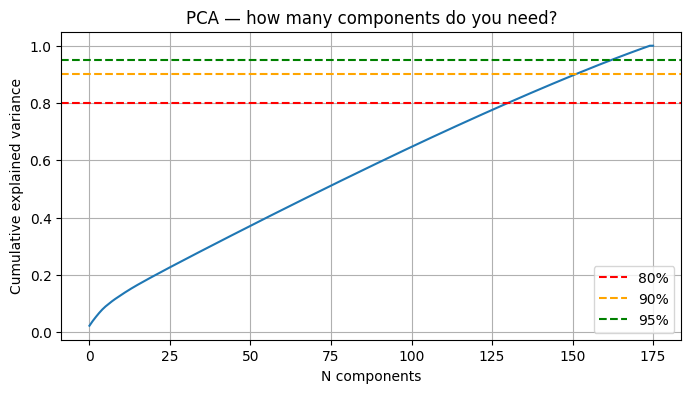

  80% variance → 131 components
  90% variance → 152 components
  95% variance → 163 components


In [60]:
# Load spikes fresh for diagnosis
spikes_diag, _ = load_all_nwb(TRAINING_DIR, FalconTask[TASK])
scaler_diag = StandardScaler()
spikes_scaled = scaler_diag.fit_transform(spikes_diag)

pca_diag = PCA().fit(spikes_scaled)
cumvar = np.cumsum(pca_diag.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.80, color='r',      linestyle='--', label='80%')
plt.axhline(0.90, color='orange', linestyle='--', label='90%')
plt.axhline(0.95, color='g',      linestyle='--', label='95%')
plt.xlabel("N components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — how many components do you need?")
plt.legend()
plt.grid(True)
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"  {threshold:.0%} variance → {n} components")

## 6) Decoder class

In [62]:
class FMLatentDecoder(BCIDecoder):
    """
    FM-Latent: Flow Matching decoder in PCA-compressed spike space.

    Online inference pipeline per timestep
    1. Accumulate HISTORY_LEN bins
    2. Flatten thenStandardScaler then PCA then (1, latent_dim)
    3. Euler ODE then (1, out_dim)
    4. Inverse-scale then raw covariate prediction
    """

    def __init__(self, task_config: FalconConfig, batch_size: int = 1):
        super().__init__(task_config, batch_size)
        self.task_config   = task_config
        self.pca           : Optional[PCA]            = None
        self.spike_scaler  : Optional[StandardScaler] = None
        self.target_scaler : Optional[StandardScaler] = None
        self.model         : Optional[VelocityField]  = None
        self._history      : list[np.ndarray]         = []


    def fit(self, training_dir: str, task: FalconTask = FalconTask.h1):
        print("=== Loading held-in calibration data ===")
        spikes, targets = load_all_nwb(training_dir, task)
        print(f"  Spikes:  {spikes.shape}  |  Targets: {targets.shape}")

        N = len(spikes)
        n_val = int(N * VAL_FRAC)
        n_tr  = N - n_val
        print(f"  Train: {n_tr}  |  Val: {n_val}  ({VAL_FRAC:.0%} held out)")

        spikes_tr,  spikes_val  = spikes[:n_tr],  spikes[n_tr:]
        targets_tr, targets_val = targets[:n_tr], targets[n_tr:]

        # Fit spike scaler on train only 
        self.spike_scaler = StandardScaler()
        spikes_tr_sc  = self.spike_scaler.fit_transform(spikes_tr)
        spikes_val_sc = self.spike_scaler.transform(spikes_val)

        print(f"  Fitting PCA ({LATENT_DIM} components)…")
        self.pca = PCA(n_components=LATENT_DIM)
        h_train  = self.pca.fit_transform(spikes_tr_sc).astype(np.float32)
        h_val    = self.pca.transform(spikes_val_sc).astype(np.float32)
        print(f"  Explained variance (sum): {self.pca.explained_variance_ratio_.sum():.3f}")

        self.target_scaler = StandardScaler()
        y_train = self.target_scaler.fit_transform(targets_tr).astype(np.float32)
        y_val   = self.target_scaler.transform(targets_val).astype(np.float32)

        out_dim = y_train.shape[1]
        self.model = VelocityField(out_dim=out_dim, latent_dim=LATENT_DIM).to(DEVICE)
        self._train(h_train, y_train, h_val, y_val)


    def _train(self, h_tr, y_tr, h_val=None, y_val=None, epochs=EPOCHS, lr=LR):
        loader    = DataLoader(TensorDataset(torch.tensor(h_tr), torch.tensor(y_tr)),
                            batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
        warmup  = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
        cosine  = CosineAnnealingLR(optimizer, T_max=epochs - 5)
        scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

        do_val = h_val is not None and y_val is not None
        if do_val:
            val_loader = DataLoader(
                TensorDataset(torch.tensor(h_val), torch.tensor(y_val)),
                batch_size=BATCH_SIZE, shuffle=False)
            h_val_t = torch.tensor(h_val, device=DEVICE)

        best_val_loss, best_state, no_improve = float("inf"), None, 0
        self.train_losses = []
        self.val_losses   = []
        self.val_r2s      = []

        self.model.train()
        for epoch in range(1, epochs + 1):
            total_tr = sum(
                self._step(optimizer, hb.to(DEVICE), yb.to(DEVICE))
                for hb, yb in loader
            )
            scheduler.step()
            avg_tr = total_tr / len(loader)
            self.train_losses.append(avg_tr)

            if do_val:
                self.model.eval()
                with torch.no_grad():
                    avg_val = sum(
                        fm_loss(self.model, hb.to(DEVICE), yb.to(DEVICE)).item()
                        for hb, yb in val_loader
                    ) / len(val_loader)
                    self.val_losses.append(avg_val)

                    if epoch % R2_EVAL_EVERY == 0 or epoch == 1:
                        y_hat      = euler_integrate(self.model, h_val_t).cpu().numpy()
                        y_hat_orig = self.target_scaler.inverse_transform(y_hat)
                        y_val_orig = self.target_scaler.inverse_transform(y_val)  # fixed
                        mean_r2    = float(r2_score(y_val_orig, y_hat_orig, multioutput="raw_values").mean())
                        self.val_r2s.append((epoch, mean_r2))

                self.model.train()

                if avg_val < best_val_loss:
                    best_val_loss = avg_val
                    best_state    = copy.deepcopy(self.model.state_dict())
                    no_improve    = 0
                else:
                    no_improve += 1

                if epoch % 10 == 0 or epoch == 1:
                    r2_str = f"  val_r2={self.val_r2s[-1][1]:.3f}" if self.val_r2s and self.val_r2s[-1][0] == epoch else ""
                    print(f"  Epoch {epoch:4d}/{epochs}  train={avg_tr:.5f}  val={avg_val:.5f}  "
                        f"best={best_val_loss:.5f}  patience={no_improve}/{PATIENCE}{r2_str}")

                if no_improve >= PATIENCE:
                    print(f"  Early stopping at epoch {epoch}.")
                    break
            else:
                self.val_losses.append(None)
                if epoch % 10 == 0 or epoch == 1:
                    print(f"  Epoch {epoch:4d}/{epochs}  train={avg_tr:.5f}")

        if do_val and best_state is not None:
            self.model.load_state_dict(best_state)
            print(f"  Restored best weights (val={best_val_loss:.5f})")
        self.model.eval()


    def _step(self, optimizer, h, y):
        optimizer.zero_grad()
        loss = fm_loss(self.model, h, y)
        loss.backward()
        nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        optimizer.step()
        return loss.item()

    def evaluate(self, test_dir: str, task: FalconTask = FalconTask.h1) -> dict:
        """
        Run streaming inference on held-out-calib data and report R² / RMSE.
        """
        print(f"\n=== Evaluating on: {test_dir} ===")
        spikes, targets = load_all_nwb(test_dir, task)

        self.reset()
        preds = np.concatenate(
            [self.predict(spikes[i : i + 1]) for i in range(len(spikes))]
        )

        r2   = r2_score(targets, preds, multioutput="raw_values")
        rmse = np.sqrt(np.mean((targets - preds) ** 2, axis=0))

        print(f"\n  {'Dim':<6} {'R²':>10} {'RMSE':>10}")
        print(f"  {'-'*28}")
        for i, (r, e) in enumerate(zip(r2, rmse)):
            print(f"  {i:<6} {r:>10.4f} {e:>10.4f}")
        print(f"  {'-'*28}")
        print(f"  {'Mean':<6} {r2.mean():>10.4f} {rmse.mean():>10.4f}")

        return {"r2_per_dim": r2, "rmse_per_dim": rmse,
                "mean_r2": float(r2.mean()), "mean_rmse": float(rmse.mean())}


    def save(self, path: str):
        import pickle
        os.makedirs(path, exist_ok=True)
        torch.save(self.model.state_dict(), os.path.join(path, "model.pt"))
        for name, obj in [("pca", self.pca), ("spike_scaler", self.spike_scaler),
                          ("target_scaler", self.target_scaler)]:
            with open(os.path.join(path, f"{name}.pkl"), "wb") as f:
                pickle.dump(obj, f)
        meta = {"out_dim": self.model.out_dim, "latent_dim": LATENT_DIM,
                "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS,
                "history_len": HISTORY_LEN, "n_channels": self.task_config.n_channels}
        with open(os.path.join(path, "meta.pkl"), "wb") as f:
            pickle.dump(meta, f)
        print(f"Saved to {path}")

    def load(self, path: str):
        import pickle
        with open(os.path.join(path, "meta.pkl"),          "rb") as f: meta = pickle.load(f)
        with open(os.path.join(path, "pca.pkl"),           "rb") as f: self.pca = pickle.load(f)
        with open(os.path.join(path, "spike_scaler.pkl"),  "rb") as f: self.spike_scaler = pickle.load(f)
        with open(os.path.join(path, "target_scaler.pkl"), "rb") as f: self.target_scaler = pickle.load(f)
        self.model = VelocityField(
            out_dim=meta["out_dim"], latent_dim=meta["latent_dim"],
            hidden_dim=meta["hidden_dim"], n_layers=meta["n_layers"]
        ).to(DEVICE)
        self.model.load_state_dict(torch.load(os.path.join(path, "model.pt"), map_location=DEVICE))
        self.model.eval()
        print(f"Loaded model from {path}")
        return meta

    def reset(self, dataset_tags: List[str] = [""]):
        self._history = []
        self.model.eval()

    def predict(self, neural_observations: np.ndarray) -> np.ndarray:
        self._history.append(neural_observations.astype(np.float32))
        if len(self._history) > HISTORY_LEN:
            self._history.pop(0)
        while len(self._history) < HISTORY_LEN:
            self._history.insert(0, np.zeros_like(neural_observations, dtype=np.float32))

        window = np.concatenate(self._history, axis=-1)
        h = self.pca.transform(self.spike_scaler.transform(window)).astype(np.float32)
        with torch.no_grad():
            y_pred = euler_integrate(self.model, torch.tensor(h, device=DEVICE))
        return self.target_scaler.inverse_transform(y_pred.cpu().numpy())

    def observe(self, neural_observations: np.ndarray):
        self._history.append(neural_observations.astype(np.float32))
        if len(self._history) > HISTORY_LEN:
            self._history.pop(0)

    def on_done(self, dones: np.ndarray):
        if dones.any():
            self._history = []

## 7) Train

In [63]:
task_enum = FalconTask[TASK]
cfg= FalconConfig(task=task_enum)
decoder= FMLatentDecoder(task_config=cfg)

decoder.fit(training_dir=TRAINING_DIR, task=task_enum)

=== Loading held-in calibration data ===
Found 13 NWB files in data/h1/held_in_calib/sub-HumanPitt-held-in-calib
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb: kept 10559 / 10819 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb: kept 6213 / 6456 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb: kept 11926 / 12233 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb: kept 6670 / 6786 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb: kept 6331 / 6505 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb: kept 11284 / 11646 samples
  data/h1/held_in_calib/sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250113T121303.n

## 8) Plot Training Metrics

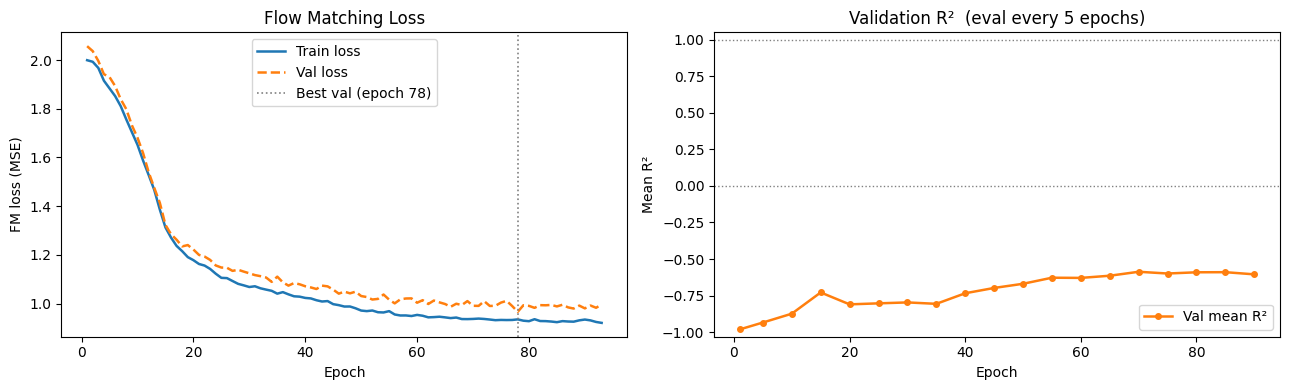

In [64]:
epochs_axis = range(1, len(decoder.train_losses) + 1)
has_val = any(v is not None for v in decoder.val_losses)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


ax = axes[0]
ax.plot(epochs_axis, decoder.train_losses, label="Train loss", linewidth=1.8)
if has_val:
    ax.plot(epochs_axis, decoder.val_losses, label="Val loss",
            linewidth=1.8, linestyle="--")
    best_epoch = int(np.argmin(decoder.val_losses)) + 1
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1.2,
               label=f"Best val (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("FM loss (MSE)")
ax.set_title("Flow Matching Loss")
ax.legend()


ax = axes[1]
if decoder.val_r2s:
    r2_epochs, r2_vals = zip(*decoder.val_r2s)
    ax.plot(r2_epochs, r2_vals, color="tab:orange", marker="o",
            markersize=4, linewidth=1.8, label="Val mean R²")
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)
    ax.axhline(1, color="grey", linestyle=":", linewidth=1)
    ax.set_ylim(min(0, min(r2_vals)) - 0.05, 1.05)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean R²")
    ax.set_title(f"Validation R²  (eval every {R2_EVAL_EVERY} epochs)")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No validation R² recorded\n(set do_val=True)",
            ha="center", va="center", transform=ax.transAxes, color="grey")

fig.tight_layout()
plt.show()

## 9) Save checkpoint

In [65]:
decoder.save(SAVE_DIR)


Saved to /content/drive/MyDrive/


## 10) Evaluate on held-out calibration data

In [66]:
metrics_held_out = decoder.evaluate(test_dir=TEST_DIR, task=task_enum)
metrics_minival  = decoder.evaluate(test_dir=MINIVAL_DIR, task=task_enum)

print(f"\nSummary")
print(f"  Held-out  Mean R²  : {metrics_held_out['mean_r2']:.4f}")
print(f"  Held-out  Mean RMSE: {metrics_held_out['mean_rmse']:.4f}")
print(f"  Minival   Mean R²  : {metrics_minival['mean_r2']:.4f}  (FALCON sklearn baseline: 0.195)")
print(f"  Minival   Mean RMSE: {metrics_minival['mean_rmse']:.4f}")


=== Evaluating on: data/h1/held_out_calib/sub-HumanPitt-held-out-calib ===
Found 14 NWB files in data/h1/held_out_calib/sub-HumanPitt-held-out-calib
  data/h1/held_out_calib/sub-HumanPitt-held-out-calib/sub-HumanPitt-held-out-calib_ses-19250126T113454.nwb: kept 2313 / 2376 samples
  data/h1/held_out_calib/sub-HumanPitt-held-out-calib/sub-HumanPitt-held-out-calib_ses-19250126T114029.nwb: kept 2350 / 2408 samples
  data/h1/held_out_calib/sub-HumanPitt-held-out-calib/sub-HumanPitt-held-out-calib_ses-19250127T120333.nwb: kept 2387 / 2454 samples
  data/h1/held_out_calib/sub-HumanPitt-held-out-calib/sub-HumanPitt-held-out-calib_ses-19250127T120826.nwb: kept 2554 / 2647 samples
  data/h1/held_out_calib/sub-HumanPitt-held-out-calib/sub-HumanPitt-held-out-calib_ses-19250129T112555.nwb: kept 2418 / 2469 samples
  data/h1/held_out_calib/sub-HumanPitt-held-out-calib/sub-HumanPitt-held-out-calib_ses-19250129T113059.nwb: kept 2289 / 2347 samples
  data/h1/held_out_calib/sub-HumanPitt-held-out-cali

## 11) Load a saved checkpoint and re-evaluate 

In [ ]:
# Useful if the Colab session restarted and you want to skip retraining.
# Uncomment and run:

# decoder2 = FMLatentDecoder(task_config=cfg)
# decoder2.load(SAVE_DIR)
# metrics2 = decoder2.evaluate(test_dir=TEST_DIR, task=task_enum)